# Tercer examen parcial
## Sistemas Inteligentes II
# primer punto


In [1]:
%pip install -q ucimlrepo imbalanced-learn scikit-learn pandas seaborn matplotlib graphviz
# If you already have the packages installed, this will be fast. Run this cell only if needed.

Note: you may need to restart the kernel to use updated packages.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set(style='whitegrid')
%matplotlib inline


en este paso carga los datos en memoria y verifica su formato (shapes, nombres de columnas).
Descarga el dataset Bank Marketing desde el repositorio UCI usando `fetch_ucirepo(id=222)`, extrae las características y la variable objetivo y las convierte en estructuras pandas (DataFrame/Series).


In [30]:
# Fetch Bank Marketing dataset from UCI repository (ID 222)
bank = fetch_ucirepo(id=222)

# Extract features and target
X = bank.data.features
y = bank.data.targets['y']  # Extract the 'y' column directly

# Ensure pandas structures
if not isinstance(X, pd.DataFrame):
    try:
        cols = bank.data.feature_names
    except Exception:
        cols = None
    X = pd.DataFrame(X, columns=cols)

# Convert y to series if it isn't already
if not isinstance(y, pd.Series):
    y = pd.Series(y, name='y')

print('X shape:', X.shape)
print('y shape:', y.shape)

display(X.head())
print('\nTarget value counts:')
print(y.value_counts())


X shape: (45211, 16)
y shape: (45211,)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN



Target value counts:
y
no     39922
yes     5289
Name: count, dtype: int64



Realiza una exploración inicial del DataFrame: muestra información del dataframe (info, describe), cuenta valores nulos y visualiza la distribución de la variable objetivo.


DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Describe (all cols):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,44923,11,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,43354,3,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,32191,2,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0



Missing values per column:
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64


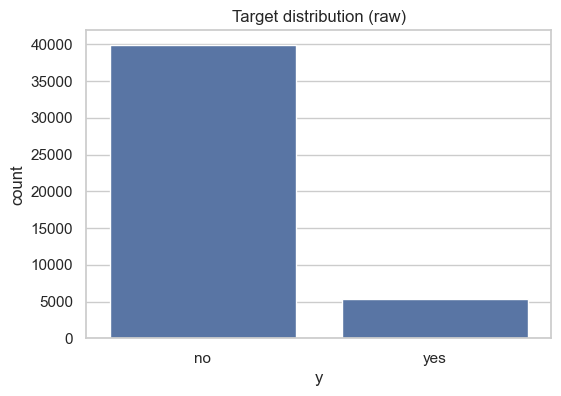

In [31]:
# Initial exploration: detailed info, describe and missing values

df = pd.concat([X, y.rename('y')], axis=1)

print('DataFrame info:')
df.info()

print('\nDescribe (all cols):')
display(df.describe(include='all').T)

print('\nMissing values per column:')
print(df.isnull().sum())

# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title('Target distribution (raw)')
plt.show()



se Realiza la limpieza y el preprocesamiento necesario: elimina la variable `duration` para evitar data leakage, codifica variables categóricas con one-hot encoding y estandariza las columnas numéricas.

El preprocesamiento transforma los datos crudos en un formato adecuado para los modelos (evita fugas de información, convierte categóricas a formato numérico y escala numéricas para modelos sensibles a la escala).


### Note: Excluding 'duration' to avoid data leakage

La variable `duration` (duración de la llamada) está fuertemente correlacionada con el target y no se conoce antes de la llamada — incluirla causaría data leakage. La dejaremos fuera del modelo predictivo y la comentaremos en las conclusiones.

In [32]:

df_proc = df.copy()
if 'duration' in df_proc.columns:
    df_proc = df_proc.drop(columns=['duration'])

X_proc = df_proc.drop(columns=['y'])
y_proc = df_proc['y'].map({'yes':1,'no':0}) if df_proc['y'].dtype == object else df_proc['y']

# One-hot encode
X_enc = pd.get_dummies(X_proc, drop_first=False)

# Scale numeric columns (after encoding, numeric names preserved)
num_cols = X_proc.select_dtypes(include=['int64','float64']).columns.tolist()
scaler = StandardScaler()
if len(num_cols) > 0:
    X_enc[num_cols] = scaler.fit_transform(X_enc[num_cols])

print('Processed X shape:', X_enc.shape)
display(X_enc.head())


Processed X shape: (45211, 46)


,age,balance,day_of_week,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success
0,1.606965,0.256419,-1.298476,-0.569351,-0.411453,-0.25194,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,0.288529,-0.437895,-1.298476,-0.569351,-0.411453,-0.25194,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,-0.747384,-0.446762,-1.298476,-0.569351,-0.411453,-0.25194,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
3,0.571051,0.047205,-1.298476,-0.569351,-0.411453,-0.25194,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
4,-0.747384,-0.447091,-1.298476,-0.569351,-0.411453,-0.25194,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [33]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(X_enc, y_proc, test_size=0.2, stratify=y_proc, random_state=42)

print('Train class counts:\n', y_train.value_counts())
print('Test class counts:\n', y_test.value_counts())


Train class counts:
 y
0    31937
1     4231
Name: count, dtype: int64
Test class counts:
 y
0    7985
1    1058
Name: count, dtype: int64


Before SMOTE (train):
y
0    31937
1     4231
Name: count, dtype: int64

After SMOTE (train):
y
0    31937
1    31937
Name: count, dtype: int64


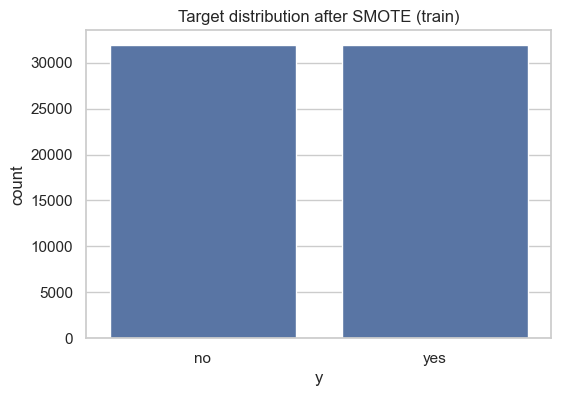

In [25]:
# Apply SMOTE on the training data only

print('Before SMOTE (train):')
print(y_train.value_counts())

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print('\nAfter SMOTE (train):')
print(pd.Series(y_res).value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y_res)
plt.title('Target distribution after SMOTE (train)')
plt.xticks([0,1], ['no','yes'])
plt.show()


Best params: {'max_depth': None, 'min_samples_split': 5}
Accuracy: 0.8252792214972907
              precision    recall  f1-score   support

          no       0.91      0.89      0.90      7985
         yes       0.30      0.36      0.32      1058

    accuracy                           0.83      9043
   macro avg       0.60      0.62      0.61      9043
weighted avg       0.84      0.83      0.83      9043



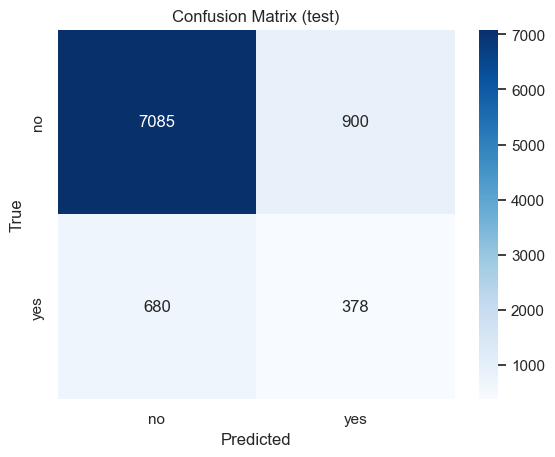

In [21]:
# Train Decision Tree with simple hyperparameter search (GridSearchCV)
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth':[3,5,8,None], 'min_samples_split':[2,5,10]}
clf = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(clf, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid.fit(X_res, y_res)
best = grid.best_estimator_
print('Best params:', grid.best_params_)

# Evaluate on test set
y_pred = best.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['no','yes']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['no','yes'], yticklabels=['no','yes'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (test)')
plt.show()


In [22]:
# Cross-validation with a pipeline that includes SMOTE (proper evaluation)
from sklearn.model_selection import cross_validate
pipeline = Pipeline([('smote', SMOTE(random_state=42)), ('clf', DecisionTreeClassifier(random_state=42))])

scores = cross_validate(pipeline, X_enc, y_proc, cv=5, scoring=['accuracy','f1_macro'], n_jobs=-1)
print('CV accuracy mean/std:', scores['test_accuracy'].mean(), scores['test_accuracy'].std())
print('CV f1_macro mean/std:', scores['test_f1_macro'].mean(), scores['test_f1_macro'].std())


CV accuracy mean/std: 0.3330707010862085 0.27283067563865665
CV f1_macro mean/std: 0.2433258124321326 0.12439196937676449


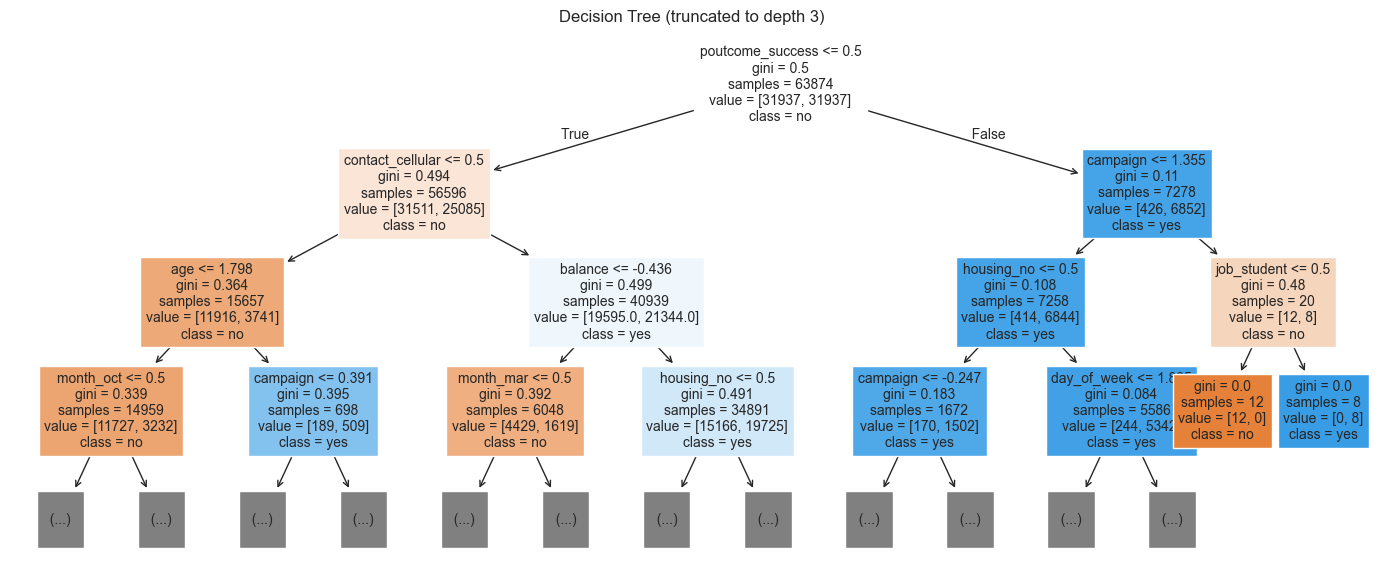

Full tree depth: 47, number of leaves: 5419
Displayed truncated tree up to depth 3 for readability.

Top rules (truncated):
|--- poutcome_success <= 0.50
|   |--- contact_cellular <= 0.50
|   |   |--- age <= 1.80
|   |   |   |--- month_oct <= 0.50
|   |   |   |   |--- truncated branch of depth 32
|   |   |   |--- month_oct >  0.50
|   |   |   |   |--- truncated branch of depth 11
|   |   |--- age >  1.80
|   |   |   |--- campaign <= 0.39
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- campaign >  0.39
|   |   |   |   |--- truncated branch of depth 7
|   |--- contact_cellular >  0.50
|   |   |--- balance <= -0.44
|   |   |   |--- month_mar <= 0.50
|   |   |   |   |--- truncated branch of depth 30
|   |   |   |--- month_mar >  0.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |--- balance >  -0.44
|   |   |   |--- housing_no <= 0.50
|   |   |   |   |--- truncated branch of depth 31
|   |   |   |--- housing_no >  0.50
|   |   |   |   |--- truncated branch of

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_21952\3862761401.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.iloc[:top_n].values, y=importances.iloc[:top_n].index, palette='viridis')


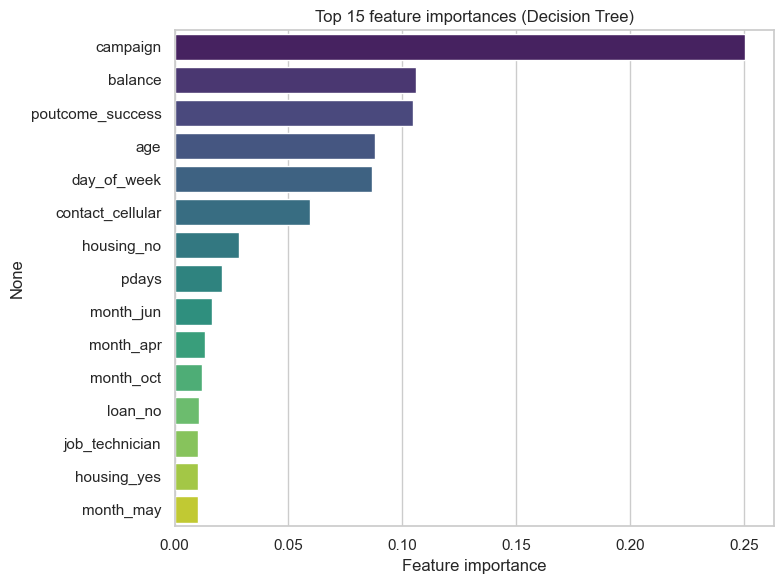

Feature Importances:
campaign               0.250653
balance                0.105771
poutcome_success       0.104525
age                    0.087985
day_of_week            0.086812
contact_cellular       0.059276
housing_no             0.028249
pdays                  0.020924
month_jun              0.016369
month_apr              0.013438
month_oct              0.012171
loan_no                0.010743
job_technician         0.010256
housing_yes            0.010202
month_may              0.010188
previous               0.010174
marital_single         0.010159
job_blue-collar        0.010065
month_mar              0.008965
job_admin.             0.008388
marital_married        0.008341
education_secondary    0.007981
marital_divorced       0.007684
month_jul              0.007489
job_management         0.007393
contact_telephone      0.006472
education_primary      0.006258
month_feb              0.006065
job_services           0.005828
education_tertiary     0.005661
loan_yes           

In [23]:
# Decision tree: plot a truncated/pruned view, export top rules and feature importances
# Plot a small-depth view so the tree is readable in the notebook
small_depth = 3
full_depth = getattr(best, 'get_depth', lambda: None)()
full_leaves = getattr(best, 'get_n_leaves', lambda: None)()

plt.figure(figsize=(14,6))
plot_tree(best, feature_names=X_enc.columns, class_names=['no','yes'], filled=True, max_depth=small_depth, fontsize=10)
plt.title(f'Decision Tree (truncated to depth {small_depth})')
plt.tight_layout()
plt.show()

print(f"Full tree depth: {full_depth}, number of leaves: {full_leaves}")
print(f"Displayed truncated tree up to depth {small_depth} for readability.\n")

# Export top rules (limited depth) to a text file and print a short sample
from sklearn.tree import export_text
rules_text = export_text(best, feature_names=list(X_enc.columns), max_depth=small_depth)

# Save the top rules to a file for the report
rules_path = r"c:\Users\USUARIO\Downloads\parcial 4\decision_tree_top_rules.txt"
with open(rules_path, 'w', encoding='utf-8') as f:
    f.write(rules_text)

print('Top rules (truncated):')
print(rules_text)
print(f"\nSaved truncated rules to {rules_path}")

# Also save a PNG of the truncated tree
png_path = r"c:\Users\USUARIO\Downloads\parcial 4\decision_tree_truncated.png"
plt.figure(figsize=(14,6))
plot_tree(best, feature_names=X_enc.columns, class_names=['no','yes'], filled=True, max_depth=small_depth, fontsize=10)
plt.title(f'Decision Tree (truncated to depth {small_depth})')
plt.tight_layout()
plt.savefig(png_path, bbox_inches='tight', dpi=150)
plt.close()
print(f'Saved truncated tree preview to {png_path}')

# Feature importances: show top 15 features to help interpretability
importances = pd.Series(best.feature_importances_, index=X_enc.columns).sort_values(ascending=False)
top_n = min(15, len(importances))
plt.figure(figsize=(8,6))
sns.barplot(x=importances.iloc[:top_n].values, y=importances.iloc[:top_n].index, palette='viridis')
plt.xlabel('Feature importance')
plt.title(f'Top {top_n} feature importances (Decision Tree)')
plt.tight_layout()
plt.show()

# Save importances to CSV for later reference
# Mostrar las importancias de características
print("Feature Importances:")
print(importances)
print("\nDataFrame de importancias:")
print(importances.to_string())
